Trajectory Time Series Diffusion Model
Supporting Reverse SDE & Probability Flow ODE
Initializing trajectory time series diffusion model...
Displaying real trajectories...


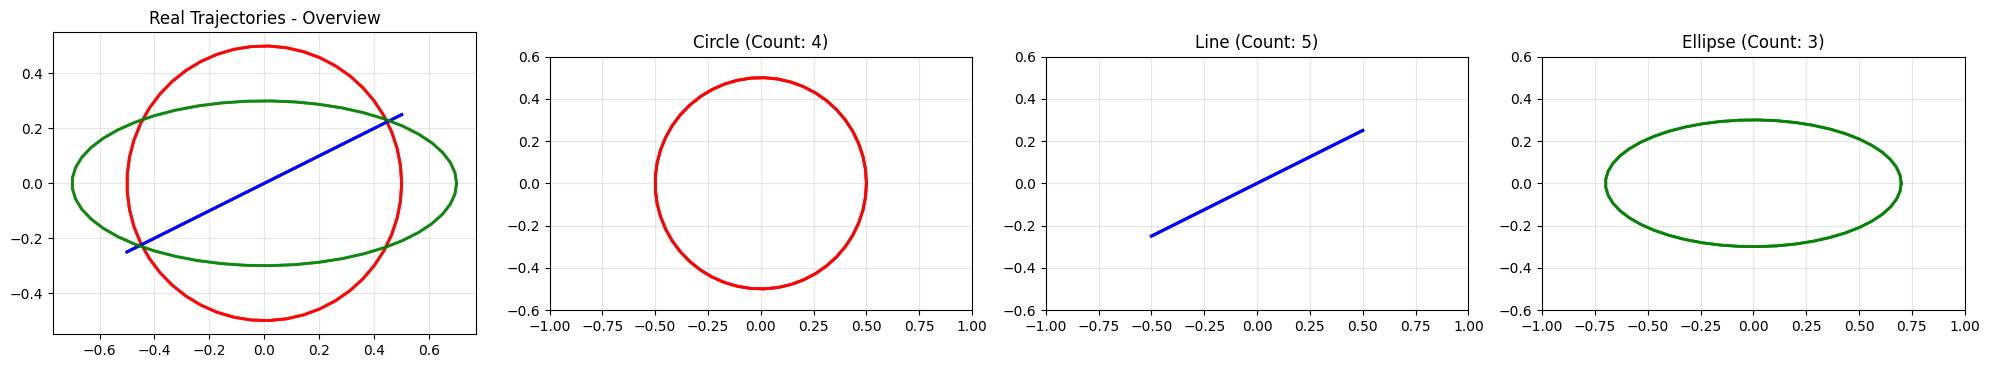

Model parameters: 204,034
Starting training...


Training:  23%|██▎       | 232/1000 [00:01<00:04, 180.87it/s, Loss=0.015385]

Epoch 200, Loss: 0.015422


Training:  43%|████▎     | 431/1000 [00:02<00:02, 193.94it/s, Loss=0.015424]

Epoch 400, Loss: 0.026604


...

Epoch 600, Loss: 0.013744


Training:  82%|████████▏ | 820/1000 [00:04<00:00, 196.22it/s, Loss=0.012551]

Epoch 800, Loss: 0.011880


Training: 100%|██████████| 1000/1000 [00:05<00:00, 179.04it/s, Loss=0.014454]


Epoch 1000, Loss: 0.014454


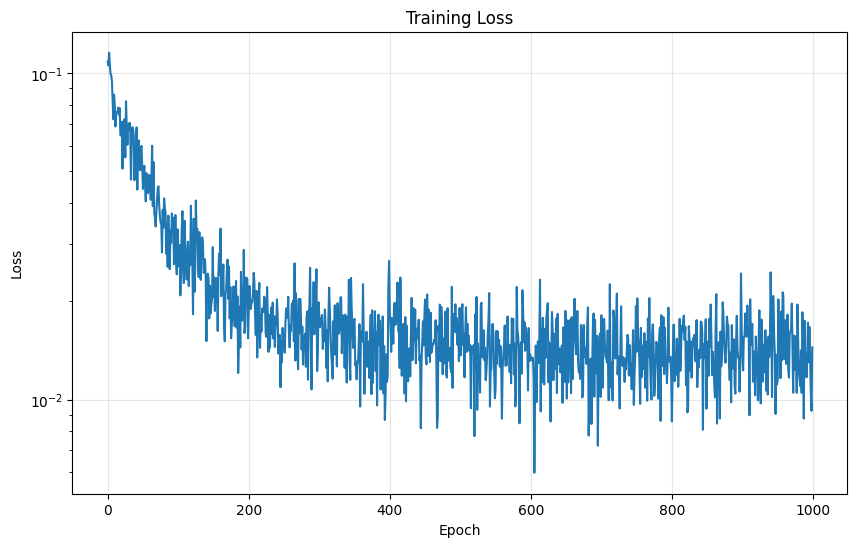


Method 1: Probability Flow ODE (Deterministic)
Generating trajectories using ODE...


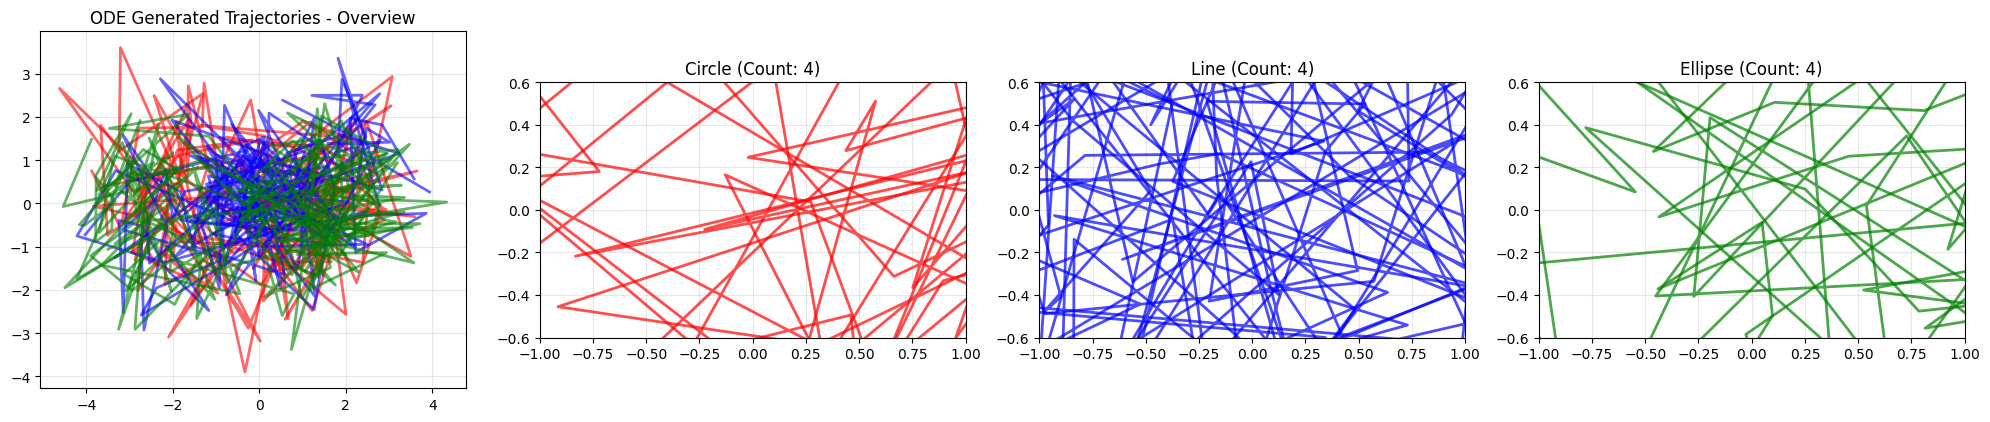


Method 2: Reverse SDE (Stochastic)
Generating trajectories using SDE...


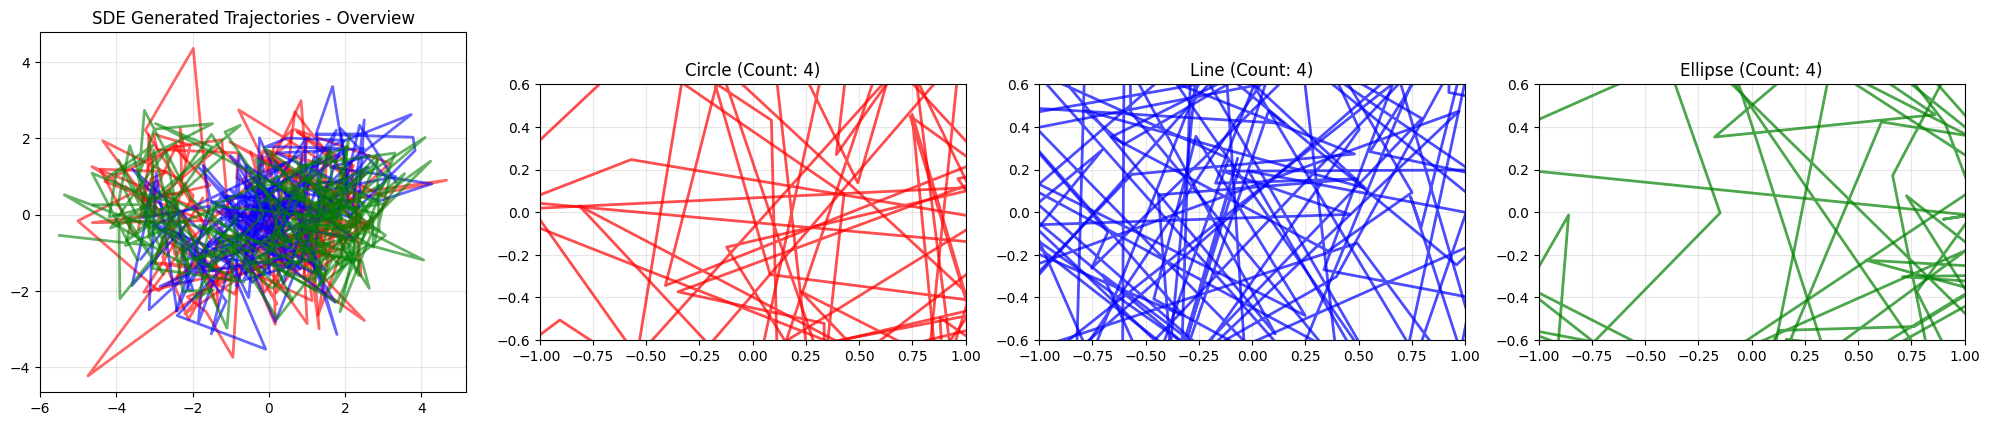


Comparison:
- ODE: Deterministic, same input -> same output
- SDE: Stochastic, more diversity in generation


In [ ]:
import torch
import torch.nn as nn
import math
import numpy as np
import matplotlib.pyplot as plt
from abc import ABC, abstractmethod
from typing import Tuple, Optional, List
from tqdm import tqdm

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

# 加入了新的Flow ODE和reverse SDE
    @abstractmethod
    def sample(self, num_samples: int) -> Tuple[torch.Tensor, Optional[torch.Tensor]]:
        pass

class ConditionalProbabilityPath(nn.Module, ABC):
    def __init__(self, p_simple: Sampleable, p_data: Sampleable):
        super().__init__()
        self.p_simple = p_simple
        self.p_data = p_data

    def sample_marginal_path(self, t: torch.Tensor) -> torch.Tensor:
        num_samples = t.shape[0]
        z, _ = self.sample_conditioning_variable(num_samples)
        x = self.sample_conditional_path(z, t)
        return x

    @abstractmethod
    def sample_conditioning_variable(self, num_samples: int) -> Tuple[torch.Tensor, torch.Tensor]:
        pass

    @abstractmethod  
    def sample_conditional_path(self, z: torch.Tensor, t: torch.Tensor) -> torch.Tensor:
        pass

# =========================== 轨迹数据集 ===========================
class SimpleTrajectoryDataset(Sampleable):
    def __init__(self, seq_len=50, dim=2, num_classes=3):
        self.seq_len = seq_len
        self.dim = dim
        self.num_classes = num_classes
    
    def sample(self, num_samples: int) -> Tuple[torch.Tensor, Optional[torch.Tensor]]:
        labels = torch.randint(0, self.num_classes, (num_samples,))
        trajectories = []
        
        for label in labels:
            label_val = label.item()
            t = np.linspace(0, 2*np.pi, self.seq_len)
            
            if label_val == 0:  # 圆形
                x = np.cos(t) * 0.5
                y = np.sin(t) * 0.5
                traj = np.stack([x, y], axis=-1)
            elif label_val == 1:  # 直线
                x = np.linspace(-0.5, 0.5, self.seq_len)
                y = x * 0.5
                traj = np.stack([x, y], axis=-1)
            else:  # 椭圆
                x = np.cos(t) * 0.7
                y = np.sin(t) * 0.3
                traj = np.stack([x, y], axis=-1)
            
            trajectories.append(traj)
        
        trajectories = torch.tensor(np.array(trajectories), dtype=torch.float32).to(device)
        return trajectories, labels.to(device)

class TrajectoryNoise(Sampleable):
    def __init__(self, seq_len=50, dim=2):
        self.seq_len = seq_len
        self.dim = dim
    
    def sample(self, num_samples: int) -> Tuple[torch.Tensor, Optional[torch.Tensor]]:
        trajectories = torch.randn(num_samples, self.seq_len, self.dim).to(device)
        return trajectories, None

# =========================== Alpha/Beta 系数 ===========================
class LinearAlpha(nn.Module):
    def forward(self, t):
        return t.squeeze()

class LinearBeta(nn.Module):
    def forward(self, t):
        return 1 - t.squeeze()

# =========================== 时间编码器 ===========================
class FourierEncoder(nn.Module):
    def __init__(self, dim: int):
        super().__init__()
        assert dim % 2 == 0
        self.half_dim = dim // 2
        self.weights = nn.Parameter(torch.randn(1, self.half_dim))

    def forward(self, t: torch.Tensor) -> torch.Tensor:
        t = t.view(-1, 1)
        freqs = t * self.weights * 2 * math.pi
        sin_embed = torch.sin(freqs)
        cos_embed = torch.cos(freqs)
        return torch.cat([sin_embed, cos_embed], dim=-1) * math.sqrt(2)

# =========================== Conv1d U-Net ===========================
class SimpleTrajectoryUNet(nn.Module):
    def __init__(self, 
                 seq_len: int = 50,
                 input_dim: int = 2,
                 hidden_dims: List[int] = [64, 128],
                 t_embed_dim: int = 64,
                 y_embed_dim: int = 32,
                 num_classes: int = 3): 
        super().__init__()
        
        self.input_proj = nn.Linear(input_dim, hidden_dims[0])
        self.time_embedder = FourierEncoder(t_embed_dim)
        self.y_embedder = nn.Embedding(num_classes, y_embed_dim)
        self.time_proj = nn.Linear(t_embed_dim, hidden_dims[0])
        self.y_proj = nn.Linear(y_embed_dim, hidden_dims[0])

        self.encoder_convs = nn.ModuleList()
        self.downsample_layers = nn.ModuleList()
        
        for i in range(len(hidden_dims) - 1):
            self.encoder_convs.append(
                nn.Sequential(
                    nn.Conv1d(hidden_dims[i], hidden_dims[i], kernel_size=3, padding=1),
                    nn.SiLU(),
                    nn.Conv1d(hidden_dims[i], hidden_dims[i], kernel_size=3, padding=1),
                    nn.SiLU()
                )
            )
            self.downsample_layers.append(
                nn.Conv1d(hidden_dims[i], hidden_dims[i+1], kernel_size=3, stride=2, padding=1)
            )
        
        self.mid_conv = nn.Sequential(
            nn.Conv1d(hidden_dims[-1], hidden_dims[-1], kernel_size=3, padding=1),
            nn.SiLU(),
            nn.Conv1d(hidden_dims[-1], hidden_dims[-1], kernel_size=3, padding=1),
            nn.SiLU()
        )
        
        self.upsample_layers = nn.ModuleList()
        self.decoder_convs = nn.ModuleList()
        
        for i in range(len(hidden_dims) - 1, 0, -1):
            self.upsample_layers.append(
                nn.Sequential(
                    nn.Upsample(scale_factor=2, mode='linear', align_corners=False),
                    nn.Conv1d(hidden_dims[i], hidden_dims[i-1], kernel_size=3, padding=1)
                )
            )
            self.decoder_convs.append(
                nn.Sequential(
                    nn.Conv1d(hidden_dims[i-1], hidden_dims[i-1], kernel_size=3, padding=1),
                    nn.SiLU(),
                    nn.Conv1d(hidden_dims[i-1], hidden_dims[i-1], kernel_size=3, padding=1),
                    nn.SiLU()
                )
            )
        
        self.output_proj = nn.Linear(hidden_dims[0], input_dim)

    def forward(self, x: torch.Tensor, t: torch.Tensor, y: torch.Tensor) -> torch.Tensor:
        bs, seq_len, input_dim = x.shape

        if t.dim() == 4:
            t = t.squeeze(-1)
        
        t_embed = self.time_embedder(t)
        y_embed = self.y_embedder(y)
        
        t_proj = self.time_proj(t_embed).unsqueeze(-1)
        y_proj = self.y_proj(y_embed).unsqueeze(-1)
        
        x = self.input_proj(x)
        x = x.transpose(1, 2)
        x = x + t_proj + y_proj
        
        skip_connections = []
        for conv, downsample in zip(self.encoder_convs, self.downsample_layers):
            x = conv(x)
            skip_connections.append(x)
            x = downsample(x)

        x = self.mid_conv(x)

        for upsample, conv in zip(self.upsample_layers, self.decoder_convs):
            x = upsample(x)
            skip = skip_connections.pop()
            x = x + skip
            x = conv(x)

        x = x.transpose(1, 2)
        x = self.output_proj(x)
        
        return x

# =========================== 条件概率路径 ===========================
class TrajectoryConditionalProbabilityPath(ConditionalProbabilityPath):
    def __init__(self, p_simple: Sampleable, p_data: Sampleable, 
                 alpha: nn.Module, beta: nn.Module):
        super().__init__(p_simple, p_data)
        self.alpha = alpha
        self.beta = beta
    
    def sample_conditioning_variable(self, num_samples: int) -> Tuple[torch.Tensor, torch.Tensor]:
        z, y = self.p_data.sample(num_samples)
        return z, y
    
    def sample_conditional_path(self, z: torch.Tensor, t: torch.Tensor) -> torch.Tensor:
        num_samples = z.shape[0]
        noise, _ = self.p_simple.sample(num_samples)
        
        alpha_t = self.alpha(t).view(-1, 1, 1)
        beta_t = self.beta(t).view(-1, 1, 1)
        
        x_t = alpha_t * z + beta_t * noise
        return x_t

# =========================== 分数网络 ===========================
class ScoreNetwork(nn.Module):
    """学习数据分布的分数函数 ∇log p_t(x)"""
    def __init__(self, unet: SimpleTrajectoryUNet):
        super().__init__()
        self.unet = unet
    
    def forward(self, x: torch.Tensor, t: torch.Tensor, y: torch.Tensor) -> torch.Tensor:
        epsilon = self.unet(x, t, y)
        return -epsilon

# =========================== 扩散采样器 ===========================
class DiffusionSampler:
    """实现反向SDE和概率流ODE采样"""
    
    def __init__(self, 
                 unet: SimpleTrajectoryUNet,
                 score_net: ScoreNetwork,
                 alpha: nn.Module,
                 beta: nn.Module,
                 device: torch.device):
        self.unet = unet
        self.score_net = score_net
        self.alpha = alpha
        self.beta = beta
        self.device = device
    
    def get_drift_diffusion(self, x: torch.Tensor, t: torch.Tensor, 
                           y: torch.Tensor, sigma_t: float = 0.1):
        """
        计算漂移项和扩散项
        通用形式: dX_t = [u_θ(X_t) + (σ_t²/2)s_θ(X_t)]dt + σ_t dW_t
        """
        epsilon_theta = self.unet(x, t, y)
        score_theta = self.score_net(x, t, y)
        
        alpha_t = self.alpha(t).view(-1, 1, 1)
        u_theta = -epsilon_theta / (alpha_t + 1e-8)
        drift = u_theta + (sigma_t ** 2 / 2) * score_theta
        
        return drift, sigma_t
    
    def sample_reverse_sde(self, 
                          num_samples: int,
                          num_steps: int = 100,
                          labels: Optional[torch.Tensor] = None,
                          sigma_schedule: str = 'linear') -> torch.Tensor:
        """反向SDE采样：dX_t = [u_θ + (σ_t²/2)s_θ]dt + σ_t dW_t"""
        self.unet.eval()
        self.score_net.eval()
        
        x = torch.randn(num_samples, 50, 2).to(self.device)
        
        if labels is None:
            labels = torch.arange(3).repeat(num_samples // 3 + 1)[:num_samples].to(self.device)
        
        dt = 1.0 / num_steps
        
        with torch.no_grad():
            for i in range(num_steps):
                t_val = 1.0 - i / num_steps
                t = torch.full((num_samples, 1, 1), t_val).to(self.device)
                
                if sigma_schedule == 'linear':
                    sigma_t = 0.1 * t_val
                elif sigma_schedule == 'constant':
                    sigma_t = 0.1
                else:
                    sigma_t = 0.1 * np.sqrt(t_val)
                
                drift, diffusion = self.get_drift_diffusion(x, t, labels, sigma_t)
                dW = torch.randn_like(x) * np.sqrt(dt)
                x = x + drift * dt + diffusion * dW
        
        return x
    
    def sample_probability_flow_ode(self,
                                   num_samples: int,
                                   num_steps: int = 100,
                                   labels: Optional[torch.Tensor] = None) -> torch.Tensor:
        """概率流ODE采样：dX_t = [u_θ + (σ_t²/2)s_θ]dt (σ_t=0)"""
        self.unet.eval()
        self.score_net.eval()
        
        x = torch.randn(num_samples, 50, 2).to(self.device)
        
        if labels is None:
            labels = torch.arange(3).repeat(num_samples // 3 + 1)[:num_samples].to(self.device)
        
        dt = 1.0 / num_steps
        
        with torch.no_grad():
            for i in range(num_steps):
                t_val = 1.0 - i / num_steps
                t = torch.full((num_samples, 1, 1), t_val).to(self.device)
                
                drift, _ = self.get_drift_diffusion(x, t, labels, sigma_t=0.0)
                x = x + drift * dt
        
        return x

# =========================== 可视化函数 ===========================
def plot_trajectories(trajectories, labels, title="Trajectories"):
    fig, axes = plt.subplots(1, 4, figsize=(20, 5))
    
    class_names = ['Circle', 'Line', 'Ellipse']
    colors = ['red', 'blue', 'green']
    
    for class_idx in range(3):
        mask = labels == class_idx
        if mask.sum() > 0:
            class_trajs = trajectories[mask]
            for traj in class_trajs:
                axes[0].plot(traj[:, 0], traj[:, 1], color=colors[class_idx], alpha=0.6, linewidth=2)
    axes[0].set_title(f'{title} - Overview')
    axes[0].set_aspect('equal')
    axes[0].grid(True, alpha=0.3)
    
    for class_idx in range(3):
        mask = labels == class_idx
        if mask.sum() > 0:
            class_trajs = trajectories[mask]
            for traj in class_trajs:
                axes[class_idx + 1].plot(traj[:, 0], traj[:, 1], color=colors[class_idx], alpha=0.7, linewidth=2)
        axes[class_idx + 1].set_title(f'{class_names[class_idx]} (Count: {mask.sum()})')
        axes[class_idx + 1].set_aspect('equal')
        axes[class_idx + 1].grid(True, alpha=0.3)
        axes[class_idx + 1].set_xlim(-1, 1)
        axes[class_idx + 1].set_ylim(-0.6, 0.6)
    
    plt.tight_layout()
    plt.show()

# =========================== 训练函数 ===========================
def train_diffusion_model():
    print("Initializing trajectory time series diffusion model...")
    
    trajectory_data = SimpleTrajectoryDataset(seq_len=50, num_classes=3)
    trajectory_noise = TrajectoryNoise(seq_len=50, dim=2)
    
    alpha = LinearAlpha()
    beta = LinearBeta()
    
    cond_path = TrajectoryConditionalProbabilityPath(trajectory_noise, trajectory_data, alpha, beta)
    
    print("Displaying real trajectories...")
    real_trajs, real_labels = trajectory_data.sample(12)
    plot_trajectories(real_trajs.cpu(), real_labels.cpu(), "Real Trajectories")
    
    unet = SimpleTrajectoryUNet(num_classes=3).to(device)
    print(f"Model parameters: {sum(p.numel() for p in unet.parameters()):,}")
    
    optimizer = torch.optim.Adam(unet.parameters(), lr=1e-3)
    criterion = nn.MSELoss()
    
    num_epochs = 1000
    batch_size = 32
    losses = []
    
    print("Starting training...")
    pbar = tqdm(range(num_epochs), desc="Training")
    
    for epoch in pbar:
        t = torch.rand(batch_size, 1, 1).to(device)
        z, y = cond_path.sample_conditioning_variable(batch_size)
        x_t = cond_path.sample_conditional_path(z, t)
        
        pred_z = unet(x_t, t, y)
        loss = criterion(pred_z, z)
        
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
        
        losses.append(loss.item())
        pbar.set_postfix({'Loss': f'{loss.item():.6f}'})
        
        if (epoch + 1) % 200 == 0:
            print(f'Epoch {epoch+1}, Loss: {loss.item():.6f}')
    
    plt.figure(figsize=(10, 6))
    plt.plot(losses)
    plt.title('Training Loss')
    plt.xlabel('Epoch')
    plt.ylabel('Loss')
    plt.yscale('log')
    plt.grid(True, alpha=0.3)
    plt.show()
    
    return unet, cond_path, losses

# =========================== 高级生成函数 ===========================
def generate_trajectories_advanced(unet, cond_path, num_samples=12, 
                                  sampling_method='ode', num_steps=100):
    print(f"Generating trajectories using {sampling_method.upper()}...")
    
    score_net = ScoreNetwork(unet).to(device)
    sampler = DiffusionSampler(unet, score_net, cond_path.alpha, 
                              cond_path.beta, device)
    
    labels = torch.arange(3).repeat(num_samples // 3 + 1)[:num_samples].to(device)
    
    if sampling_method == 'sde':
        trajectories = sampler.sample_reverse_sde(
            num_samples=num_samples,
            num_steps=num_steps,
            labels=labels,
            sigma_schedule='linear'
        )
    else:
        trajectories = sampler.sample_probability_flow_ode(
            num_samples=num_samples,
            num_steps=num_steps,
            labels=labels
        )
    
    return trajectories.cpu(), labels.cpu()

# =========================== 主程序 ===========================
def main():
    print("=" * 60)
    print("Trajectory Time Series Diffusion Model")
    print("Supporting Reverse SDE & Probability Flow ODE")
    print("=" * 60)
    
    trained_unet, cond_path, losses = train_diffusion_model()
    
    print("\n" + "=" * 60)
    print("Method 1: Probability Flow ODE (Deterministic)")
    print("=" * 60)
    gen_trajs_ode, gen_labels = generate_trajectories_advanced(
        trained_unet, cond_path, num_samples=12, 
        sampling_method='ode', num_steps=100
    )
    plot_trajectories(gen_trajs_ode, gen_labels, "ODE Generated Trajectories")
    
    print("\n" + "=" * 60)
    print("Method 2: Reverse SDE (Stochastic)")
    print("=" * 60)
    gen_trajs_sde, gen_labels = generate_trajectories_advanced(
        trained_unet, cond_path, num_samples=12,
        sampling_method='sde', num_steps=100
    )
    plot_trajectories(gen_trajs_sde, gen_labels, "SDE Generated Trajectories")
    
    print("\n" + "=" * 60)
    print("Comparison:")
    print("- ODE: Deterministic, same input -> same output")
    print("- SDE: Stochastic, more diversity in generation")
    print("=" * 60)

if __name__ == "__main__":
    main()